<a href="https://colab.research.google.com/github/hansi-2000/HR-Project_ML/blob/main/EMP_Attrition_rate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [87]:
## IMPORT LIBRARIES ##

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Import the required function for preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Import train and test split function
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Import Classifiers to be used
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# Import packages to calculate performance of the models
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, roc_auc_score

# To save the model import pickle
import pickle



In [88]:
import pandas as pd

# Train dataset
train_url = 'https://drive.google.com/uc?export=download&id=1c9kqXXxjjOjN7baMv5YXTMBiu66ZVOX3'
train = pd.read_csv(train_url)

# Test dataset
test_url = 'https://drive.google.com/uc?export=download&id=1LPXQict984HB3ipad-h4C0F7KEIBax5N'
test = pd.read_csv(test_url)

# Check if the data is loaded correctly
print(train.head())
print(test.head())


   Employee ID  Age  Gender  Years at Company    Job Role  Monthly Income  \
0         8410   31    Male                19   Education            5390   
1        64756   59  Female                 4       Media            5534   
2        30257   24  Female                10  Healthcare            8159   
3        65791   36  Female                 7   Education            3989   
4        65026   56    Male                41   Education            4821   

  Work-Life Balance Job Satisfaction Performance Rating  Number of Promotions  \
0         Excellent           Medium            Average                     2   
1              Poor             High                Low                     3   
2              Good             High                Low                     0   
3              Good             High               High                     1   
4              Fair        Very High            Average                     0   

   ... Marital Status  Number of Dependents Job Le

In [89]:
emp_data = pd.concat([train, test], ignore_index=True)

emp_data.info()

emp_data.nunique()

emp_data.isnull().sum()
print()

print("Duplicates: ",emp_data.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74498 entries, 0 to 74497
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               74498 non-null  int64 
 1   Age                       74498 non-null  int64 
 2   Gender                    74498 non-null  object
 3   Years at Company          74498 non-null  int64 
 4   Job Role                  74498 non-null  object
 5   Monthly Income            74498 non-null  int64 
 6   Work-Life Balance         74498 non-null  object
 7   Job Satisfaction          74498 non-null  object
 8   Performance Rating        74498 non-null  object
 9   Number of Promotions      74498 non-null  int64 
 10  Overtime                  74498 non-null  object
 11  Distance from Home        74498 non-null  int64 
 12  Education Level           74498 non-null  object
 13  Marital Status            74498 non-null  object
 14  Number of Dependents  

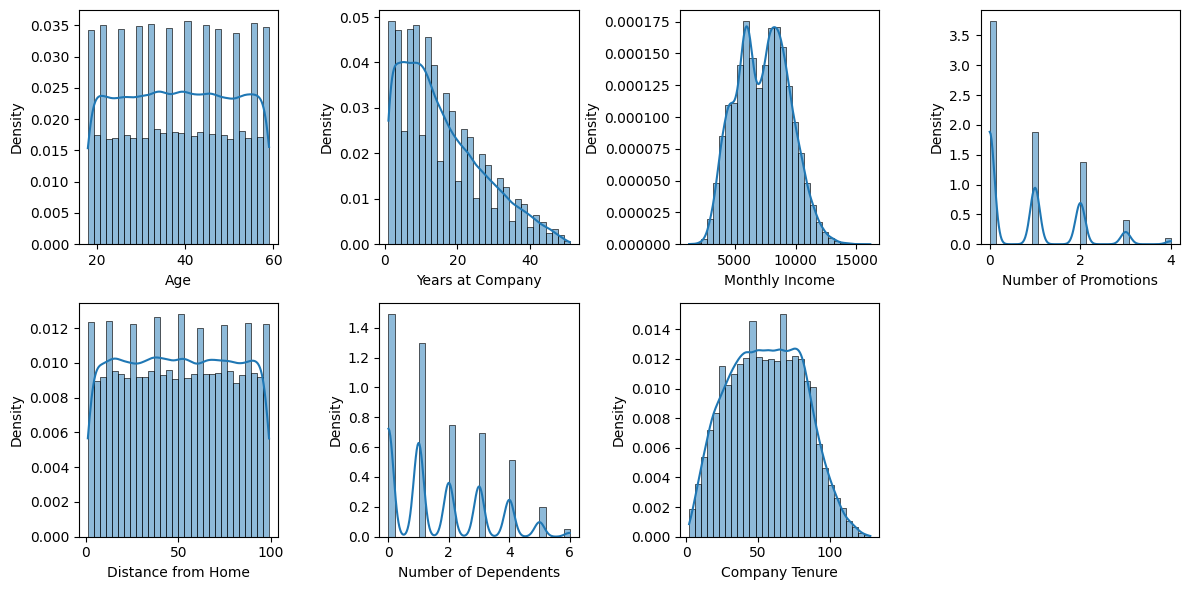

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

emp_eda = emp_data.copy()

# Assuming emp_eda is already defined and contains numeric columns
num_cols_eda = [n for n in emp_eda.columns if emp_eda[n].dtypes != 'O']

# Create a 2x4 grid of subplots (8 subplots total, we'll use 7)
fig, ax = plt.subplots(2, 4, figsize=(12, 6))
ax = ax.flatten()

# Loop over the first 7 numerical columns and create a histogram for each
for i, col in enumerate(num_cols_eda[:7]):  # Limit to 7 columns
    sns.histplot(emp_eda[col], kde=True, stat='density', bins=30, ax=ax[i])

# Hide the 8th subplot (since we only need 7 plots)
ax[7].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


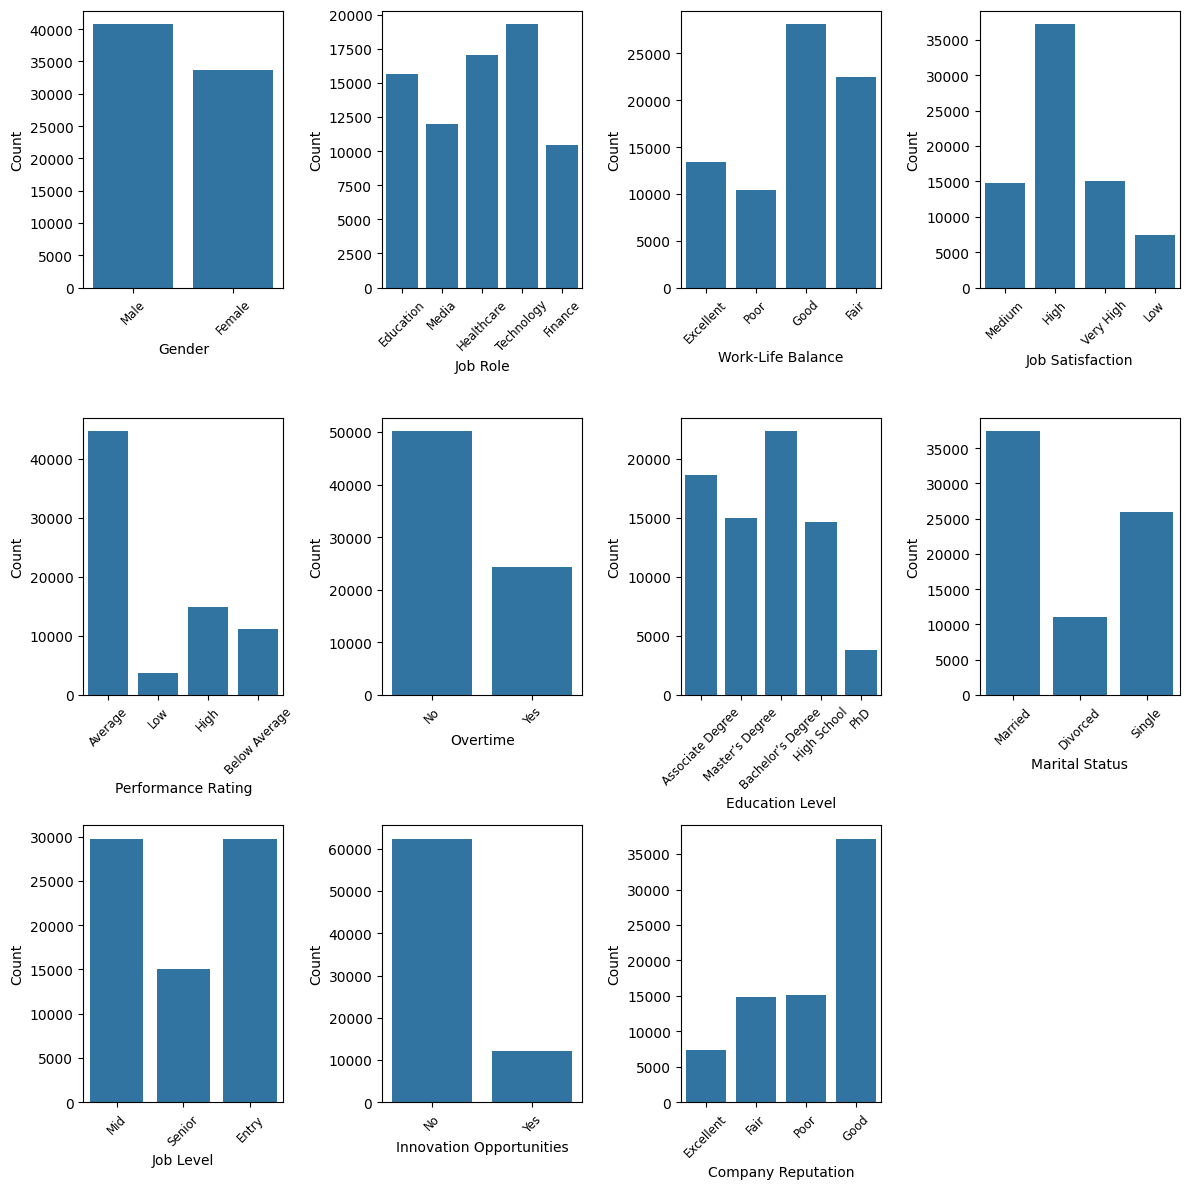

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming emp_eda is already defined and contains categorical columns
cat_cols_eda = [c for c in emp_eda.columns if emp_eda[c].dtypes == 'O']

# Create a 3x4 grid of subplots (12 subplots total)
fig, ax = plt.subplots(3, 4, figsize=(12, 12))
ax = ax.flatten()

# Loop over the first 11 categorical columns and create a countplot for each
for i, col in enumerate(cat_cols_eda[:11]):  # Limit to 11 columns
    sns.countplot(x=col, data=emp_eda, ax=ax[i])
    ax[i].set_ylabel('Count')
    ax[i].tick_params(axis='x', rotation=45, labelsize=8.5)

# Hide the 12th subplot (since we only need 11 plots)
ax[11].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


In [79]:
import pandas as pd

# Train dataset
train_url = 'https://drive.google.com/uc?export=download&id=1c9kqXXxjjOjN7baMv5YXTMBiu66ZVOX3'
train = pd.read_csv(train_url)

# Test dataset
test_url = 'https://drive.google.com/uc?export=download&id=1LPXQict984HB3ipad-h4C0F7KEIBax5N'
test = pd.read_csv(test_url)


In [80]:
# emp_data.head()
#print(emp_data.columns)

ordinal_mappings = {
    'Work-Life Balance': {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4},
    'Company Reputation': {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4},
    'Job Satisfaction': {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4},
    'Performance Rating': {'Low': 1, 'Below Average': 2, 'Average': 3, 'High': 4},
    'Education Level': {'High School': 1, 'Associate Degree': 2, 'Bachelor’s Degree': 3, 'Master’s Degree': 4, 'PhD': 5},
    'Job Level': {'Entry': 1, 'Mid': 2, 'Senior': 3},
    'Company Reputation': {'Very Poor': 0, 'Poor': 1, 'Fair':2, 'Good': 3, 'Excellent': 4},
    'Employee Recognition': {'Very Low': 0, 'Low': 1, 'Medium': 2, 'High': 3}
}


for col, mapping in ordinal_mappings.items():
    train[col] = train[col].map(mapping)
    test[col] = test[col].map(mapping)


In [81]:
# print("Unique values in Gender column:", emp_data['Gender'].unique())
binary_columns = ['Innovation Opportunities', 'Overtime', 'Attrition', 'Remote Work', 'Leadership Opportunities']

binary_mapping = {'No': 0, 'Yes': 1, 'Stayed':1, 'Left':0}

for col in binary_columns:
    train[col] = train[col].map(binary_mapping)
    test[col] = test[col].map(binary_mapping)

df = pd.concat([train, test])

df = df.drop("Employee ID", axis=1)
df = df.drop("Gender", axis=1)
df = df.drop("Job Role", axis=1)
df = df.drop("Marital Status", axis=1)

train = train.drop("Employee ID", axis=1)
train = train.drop("Gender", axis=1)
train = train.drop("Job Role", axis=1)
train = train.drop("Marital Status", axis=1)

test = test.drop("Employee ID", axis=1)
test = test.drop("Gender", axis=1)
test = test.drop("Job Role", axis=1)
test = test.drop("Marital Status", axis=1)

df.head(10)

,Age,Years at Company,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Education Level,Number of Dependents,Job Level,Employee Recognition,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Attrition
0,31,19,5390,4,2,3,2,0,22,2,0,2,2.0,89,0,0,0,4,1
1,59,4,5534,1,3,1,3,0,21,4,3,2,1.0,21,0,0,0,2,1
2,24,10,8159,3,3,1,0,0,11,3,3,2,1.0,74,0,0,0,1,1
3,36,7,3989,3,3,4,1,0,27,1,2,2,2.0,50,1,0,0,3,1
4,56,41,4821,2,4,3,0,1,71,1,0,3,2.0,68,0,0,0,2,1
5,38,3,9977,2,3,2,3,0,37,3,0,2,3.0,47,0,0,1,2,0
6,47,23,3681,2,3,4,1,1,75,1,3,1,2.0,93,0,0,0,3,0
7,48,16,11223,4,4,4,2,0,5,4,4,1,1.0,88,0,0,0,4,1
8,57,44,3773,3,2,4,1,1,39,1,4,1,2.0,75,0,0,0,2,1
9,24,1,7319,1,3,3,1,1,57,5,4,1,1.0,45,0,0,1,3,0


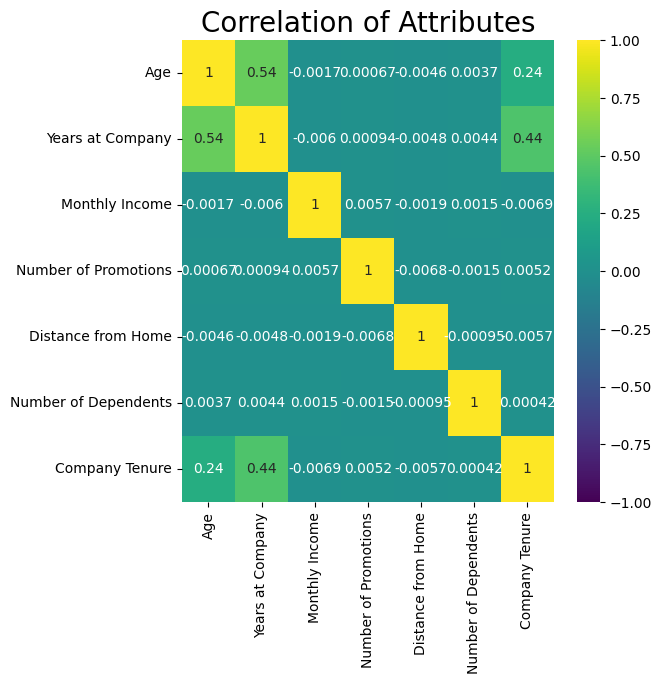

In [97]:
#emp_data = emp_data.drop(columns=['Employee ID'])

num_cols = [n for n in emp_data.columns if emp_data[n].dtypes!='O']
colormap = plt.cm.viridis
plt.figure(figsize=(6,6))
plt.title('Correlation of Attributes', size=20)
ax = sns.heatmap(emp_data[num_cols].corr(), cmap=colormap, annot=True, vmin=-1, vmax=1)
plt.show()

In [61]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Shuffle the combined dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Separate features and target variable
X = df.drop(columns=['Attrition'])  # Assuming 'Attrition' is the target column
y = df['Attrition']  # Assuming binary labels 'Stayed'/'Left'

# Step 3: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest model with adjusted hyperparameters
model = RandomForestClassifier(
    n_estimators=300,             # Increased number of trees
    max_depth=10,                 # Increased depth to allow the model to learn more complex patterns
    min_samples_leaf=20,          # Fewer restrictions to allow for more complex trees
    min_samples_split=10,         # More splits, encouraging learning from small parts of the data
    max_features='sqrt',          # Using square root of features at each split
    random_state=42,
    class_weight='balanced'       # Handle class imbalance (if present)
)

# Train the model
model.fit(X_train, y_train)

# Evaluate performance using cross-validation
cv_score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-validation accuracy:", cv_score.mean())

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate and print accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on test set:", accuracy)

# Print classification report
print("Classification Report:\n", classification_report(y_test, y_pred))


Cross-validation accuracy: 0.7185141117532157
Accuracy on test set: 0.713489932885906
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.74      0.71      7046
           1       0.75      0.69      0.72      7854

    accuracy                           0.71     14900
   macro avg       0.71      0.71      0.71     14900
weighted avg       0.72      0.71      0.71     14900



In [84]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from xgboost import XGBClassifier

# Prepare the train and test sets
X_train = train.drop(columns=['Attrition'])
y_train = train['Attrition']
X_test = test.drop(columns=['Attrition'])
y_test = test['Attrition']

# Convert target variable 'Attrition' to binary values
# y_train = y_train.apply(lambda x: 1 if x == 'Left' else 0)
# y_test = y_test.apply(lambda x: 1 if x == 'Left' else 0)

# Initialize the XGBoost model with more advanced parameters
xgb_model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
)

# Parameter grid for tuning
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 6, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'scale_pos_weight': [1, 2, 3]  # Adjust for class imbalance
}

# Use GridSearchCV to search for the best hyperparameters
grid_search = GridSearchCV(xgb_model, param_grid, cv=5, verbose=1, n_jobs=-1, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best model from grid search
best_model = grid_search.best_estimator_

# Make predictions with the best model
y_pred = best_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Classification Report
print('Classification Report:')
print(classification_report(y_test, y_pred))

# Cross-validation to get a better estimate of model performance
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='accuracy')
print(f'Cross-validation accuracy: {cv_scores.mean():.2f} ± {cv_scores.std():.2f}')


Fitting 5 folds for each of 729 candidates, totalling 3645 fits
Accuracy: 0.72
Confusion Matrix:
[[5053 1979]
 [2168 5700]]
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71      7032
           1       0.74      0.72      0.73      7868

    accuracy                           0.72     14900
   macro avg       0.72      0.72      0.72     14900
weighted avg       0.72      0.72      0.72     14900

Cross-validation accuracy: 0.72 ± 0.00
